#**Explanatory Data Analysis Pipeline — Urban Pluvial Flood Risk**



---



# **Business Context**

>Urban flooding disrupts infrastructure, damages property, and impacts city economies. This dataset enables evidence-based planning for drainage, land use, and climate resilience to reduce risk.

**Who (Audience):**
City planners, policymakers, infrastructure agencies, researchers, and insurers who need to identify high-risk zones and prioritize flood mitigation efforts.

**What (Key Message):**
The data highlights which wards and cities are most vulnerable and which environmental or infrastructure factors contribute most to flood risk.

**Why (Purpose):**
To support data-driven decisions, optimize resource allocation, and strengthen urban resilience strategies against climate-related flooding.

> Visualization Approach:
I'll use maps to show spatial risk distribution, bar/box plots to compare flood risks across wards, and correlation charts to link environmental factors with flooding severity.



# **Data Collection**

The dataset for this pipeline is taken from the source Kaggle.

Link to the dataset: https://www.kaggle.com/datasets/emanfatima2025/flood-disaster-data

Starting with the analysis. Intially, I'm loading all the required libraries. And then deal with importing the dataset using pandas and also viewing the dataset which will help in understanding the dataset for further analysis.

#**Importing Modules**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from pandas.plotting import parallel_coordinates
from scipy.ndimage import gaussian_filter1d

In [ ]:
DATA_PATH = "/content/urban_pluvial_flood_risk_dataset.csv"
df = pd.read_csv(DATA_PATH)

# quick look
df.head()

,segment_id,city_name,admin_ward,latitude,longitude,catchment_id,elevation_m,dem_source,land_use,soil_group,drainage_density_km_per_km2,storm_drain_proximity_m,storm_drain_type,rainfall_source,historical_rainfall_intensity_mm_hr,return_period_years,risk_labels
0,SEG-00001,"Colombo, Sri Lanka",Borough East,6.920633,79.912600,CAT-136,NaN,Copernicus_EEA-10_v5,Institutional,NaN,4.27,160.5,CurbInlet,ERA5,39.4,50,monitor
1,SEG-00002,"Chennai, India",Ward D,13.076487,80.281774,CAT-049,-2.19,Copernicus_EEA-10_v5,Residential,D,7.54,NaN,OpenChannel,ERA5,56.8,25,ponding_hotspot|low_lying|event_2025-05-02
2,SEG-00003,"Ahmedabad, India",Sector 12,23.019473,72.638578,CAT-023,30.88,SRTM_3arc,Industrial,B,11.00,152.5,OpenChannel,IMD,16.3,5,monitor
3,SEG-00004,"Hong Kong, China",Sector 14,22.302602,114.078673,CAT-168,24.28,SRTM_3arc,Residential,B,7.32,37.0,Manhole,ERA5,77.0,10,monitor
4,SEG-00005,"Durban, South Africa",Sector 5,-29.887602,30.911008,CAT-171,35.70,SRTM_3arc,Industrial,C,4.50,292.4,OpenChannel,ERA5,20.8,5,monitor


# **Data Exploration**

In [ ]:
print("Shape:", df.shape)
print("\nColumns and dtypes:\n", df.dtypes)
print("\nMissing values per column:")
print(df.isnull().sum().sort_values(ascending=False).head(20))

print("\nUnique risk labels:", df['risk_labels'].nunique())
print(df['risk_labels'].value_counts().nlargest(10))


Shape: (2963, 17)

Columns and dtypes:
 segment_id                              object
city_name                               object
admin_ward                              object
latitude                               float64
longitude                              float64
catchment_id                            object
elevation_m                            float64
dem_source                              object
land_use                                object
soil_group                              object
drainage_density_km_per_km2            float64
storm_drain_proximity_m                float64
storm_drain_type                        object
rainfall_source                         object
historical_rainfall_intensity_mm_hr    float64
return_period_years                      int64
risk_labels                             object
dtype: object

Missing values per column:
soil_group                             362
rainfall_source                        315
drainage_density_km_per_km2      

In this Step:
* We looked at summary & missing counts
* Displayed the count of unique risk labels and the most common ones
* This step also helps in identifies which columns have missing data and highlights that risk_labels is high-cardinality (many distinct composite labels). We use this to design cleaning: group labels into simpler categories for exploratory work.


# **Data Cleaning**

In [ ]:
df['risk_simple'] = df['risk_labels'].apply(lambda s: 'monitor' if str(s).strip() == 'monitor' else 'at_risk')

num_cols = ['elevation_m', 'drainage_density_km_per_km2', 'storm_drain_proximity_m',
            'historical_rainfall_intensity_mm_hr', 'return_period_years']
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')

df_num = df[num_cols].copy()
df_num = df_num.fillna(df_num.median())

print("After cleaning: sample rows")
display(df[['segment_id','city_name','latitude','longitude','risk_labels','risk_simple']].head())


After cleaning: sample rows


,segment_id,city_name,latitude,longitude,risk_labels,risk_simple
0,SEG-00001,"Colombo, Sri Lanka",6.920633,79.912600,monitor,monitor
1,SEG-00002,"Chennai, India",13.076487,80.281774,ponding_hotspot|low_lying|event_2025-05-02,at_risk
2,SEG-00003,"Ahmedabad, India",23.019473,72.638578,monitor,monitor
3,SEG-00004,"Hong Kong, China",22.302602,114.078673,monitor,monitor
4,SEG-00005,"Durban, South Africa",-29.887602,30.911008,monitor,monitor


After Cleaning:
* Created a simplified risk label: monitor vs at_risk.
* Converted numeric columns to numeric types and filled missing numbers with medians.
* Quick missing imputation for numeric features (median) for EDA visuals.
* Created risk_simple to compare 'monitor' vs all other risk indicators.

#**Exploratory Data Analysis**

##1) Spatial plot (latitude / longitude) showing monitor vs at_risk

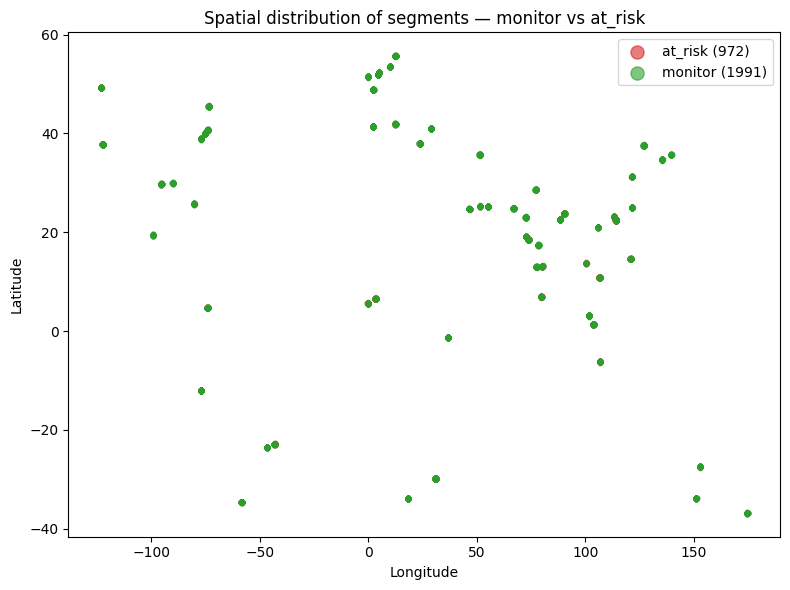

In [ ]:
plt.figure(figsize=(8,6))
colors = {'monitor':'#2ca02c','at_risk':'#d62728'}
for k, grp in df.groupby('risk_simple'):
    plt.scatter(grp['longitude'], grp['latitude'], s=10, alpha=0.6, label=f"{k} ({len(grp)})", c=colors[k])
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Spatial distribution of segments — monitor vs at_risk")
plt.legend(markerscale=3)
plt.tight_layout()
plt.show()

**What this shows:**
>You can visually spot geographic clusters of at_risk segments. A spatial scatter reveals where in the city/region these at-risk segments are concentrated.

>Targeting physical interventions (drain retrofits, temporary pumps, localized community warnings) is most effective when focusing on identified clusters rather than uniform investment across the whole city.

##2)Elevation distribution by risk

/tmp/ipython-input-4128147933.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='risk_simple', y='elevation_m', data=df, inner='quartile', palette=[colors['monitor'], colors['at_risk']])


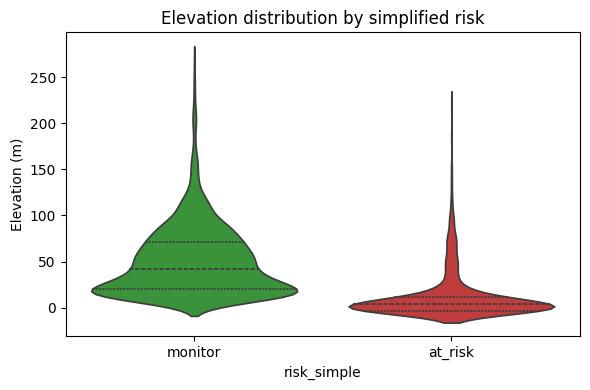

In [ ]:
plt.figure(figsize=(6,4))
sns.violinplot(x='risk_simple', y='elevation_m', data=df, inner='quartile', palette=[colors['monitor'], colors['at_risk']])
plt.title("Elevation distribution by simplified risk")
plt.ylabel("Elevation (m)")
plt.tight_layout()
plt.show()


**This shows:**
>at_risk segments often have lower elevations compared to monitor segments (look for shift of violin shapes).

>Low elevation is a clear risk factor for pluvial flooding. Prioritize elevation-sensitive measures (e.g., flood barriers, targeted land raising, or prioritized pumping) in low-elevation zones.

##3)Hexbin of drainage_density vs storm_drain_proximity

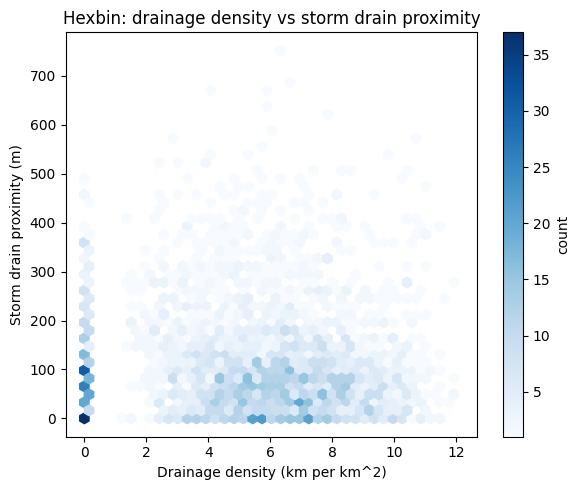

In [ ]:
plt.figure(figsize=(6,5))
hb = plt.hexbin(df['drainage_density_km_per_km2'].fillna(0), df['storm_drain_proximity_m'].fillna(0),
                gridsize=40, cmap='Blues', mincnt=1)
plt.colorbar(label='count')
plt.xlabel('Drainage density (km per km^2)')
plt.ylabel('Storm drain proximity (m)')
plt.title('Hexbin: drainage density vs storm drain proximity')
plt.tight_layout()
plt.show()


**This shows:**
>A hexbin plot summarizes the two-dimensional density. For example, clusters at low drainage density and large proximities indicate areas with sparse drainage and far from storm drains — a concerning combination.

>Where drainage density is low and storm drains are far, interventions like adding drains, improving connectivity, or localized storage (retention basins) will deliver high risk reduction per dollar.

##4)Smoothed density/histogram lines for historical rainfall intensity of top risk-types

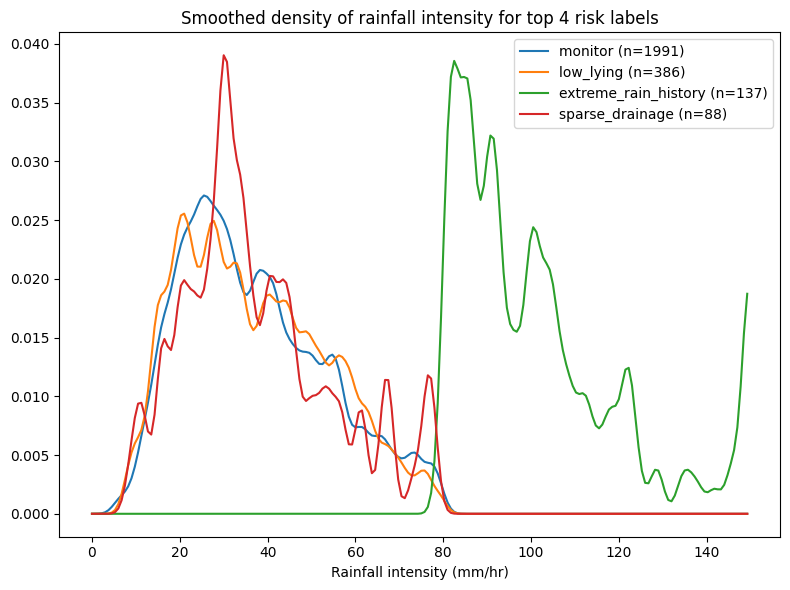

In [ ]:
from scipy.ndimage import gaussian_filter1d
top_risks = df['risk_labels'].value_counts().nlargest(4).index.tolist()

plt.figure(figsize=(8,6))
xs = np.linspace(0, df['historical_rainfall_intensity_mm_hr'].dropna().max(), 200)
for r in top_risks:
    subset = df[df['risk_labels']==r]['historical_rainfall_intensity_mm_hr'].dropna().astype(float)
    if len(subset) > 0:
        counts, bin_edges = np.histogram(subset, bins=200, range=(0, xs.max()), density=True)
        smooth = gaussian_filter1d(counts, sigma=2)
        plt.plot(bin_edges[:-1], smooth, label=f"{r} (n={len(subset)})")
plt.xlabel("Rainfall intensity (mm/hr)")
plt.title("Smoothed density of rainfall intensity for top 4 risk labels")
plt.legend()
plt.tight_layout()
plt.show()


**What this shows:**
>extreme_rain_history segments show a distinct distribution of very high rainfall intensity, while monitor, low_lying, and sparse_drainage tend to concentrate at more moderate intensities.

>Locations labeled extreme_rain_history likely experienced very high historical intensities. These areas need both short-term (warning systems) and long-term (sustainable drainage) investment.

##5)Correlation Heatmap

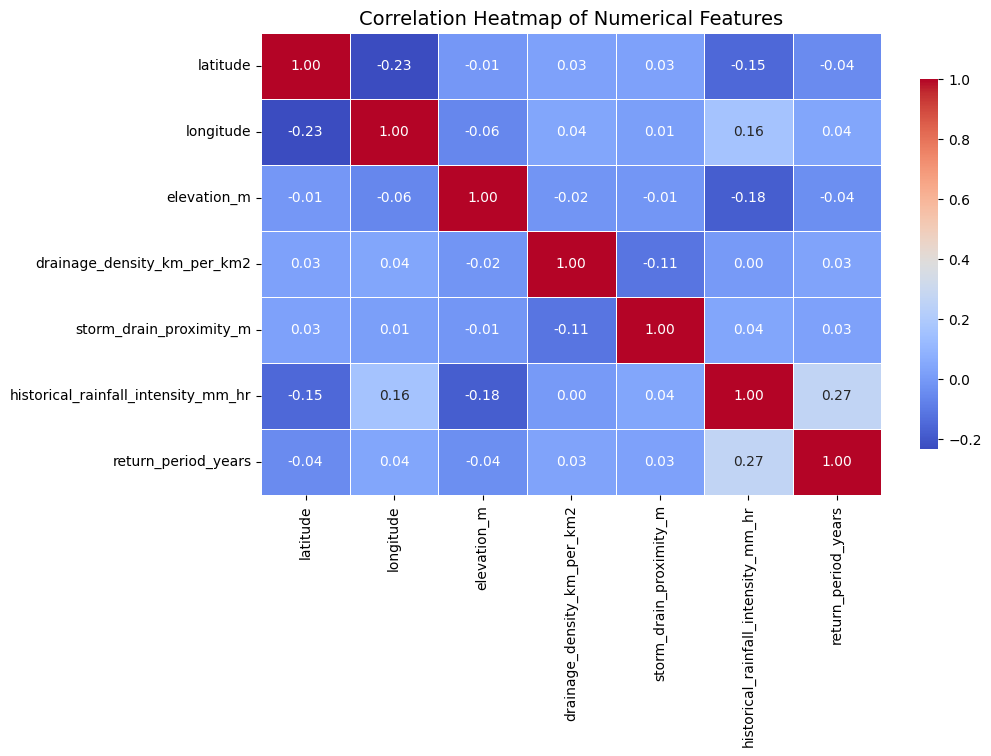

In [ ]:
plt.figure(figsize=(10, 6))
corr = df.corr(numeric_only=True)  # only numeric columns
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
plt.title("Correlation Heatmap of Numerical Features", fontsize=14)
plt.show()

Outcomes:

* Correlations among features (e.g. rainfall vs return_period vs elevation).
* Helps to spot redundancy or potential multicollinearity.
* If two features are strongly correlated, one might be dropped or combined.
* Helps in feature engineering and modeling to reduce overfitting.

# **Key Insights**

## **Insight1:** Pairwise relationships via Seaborn PairGrid with hue code

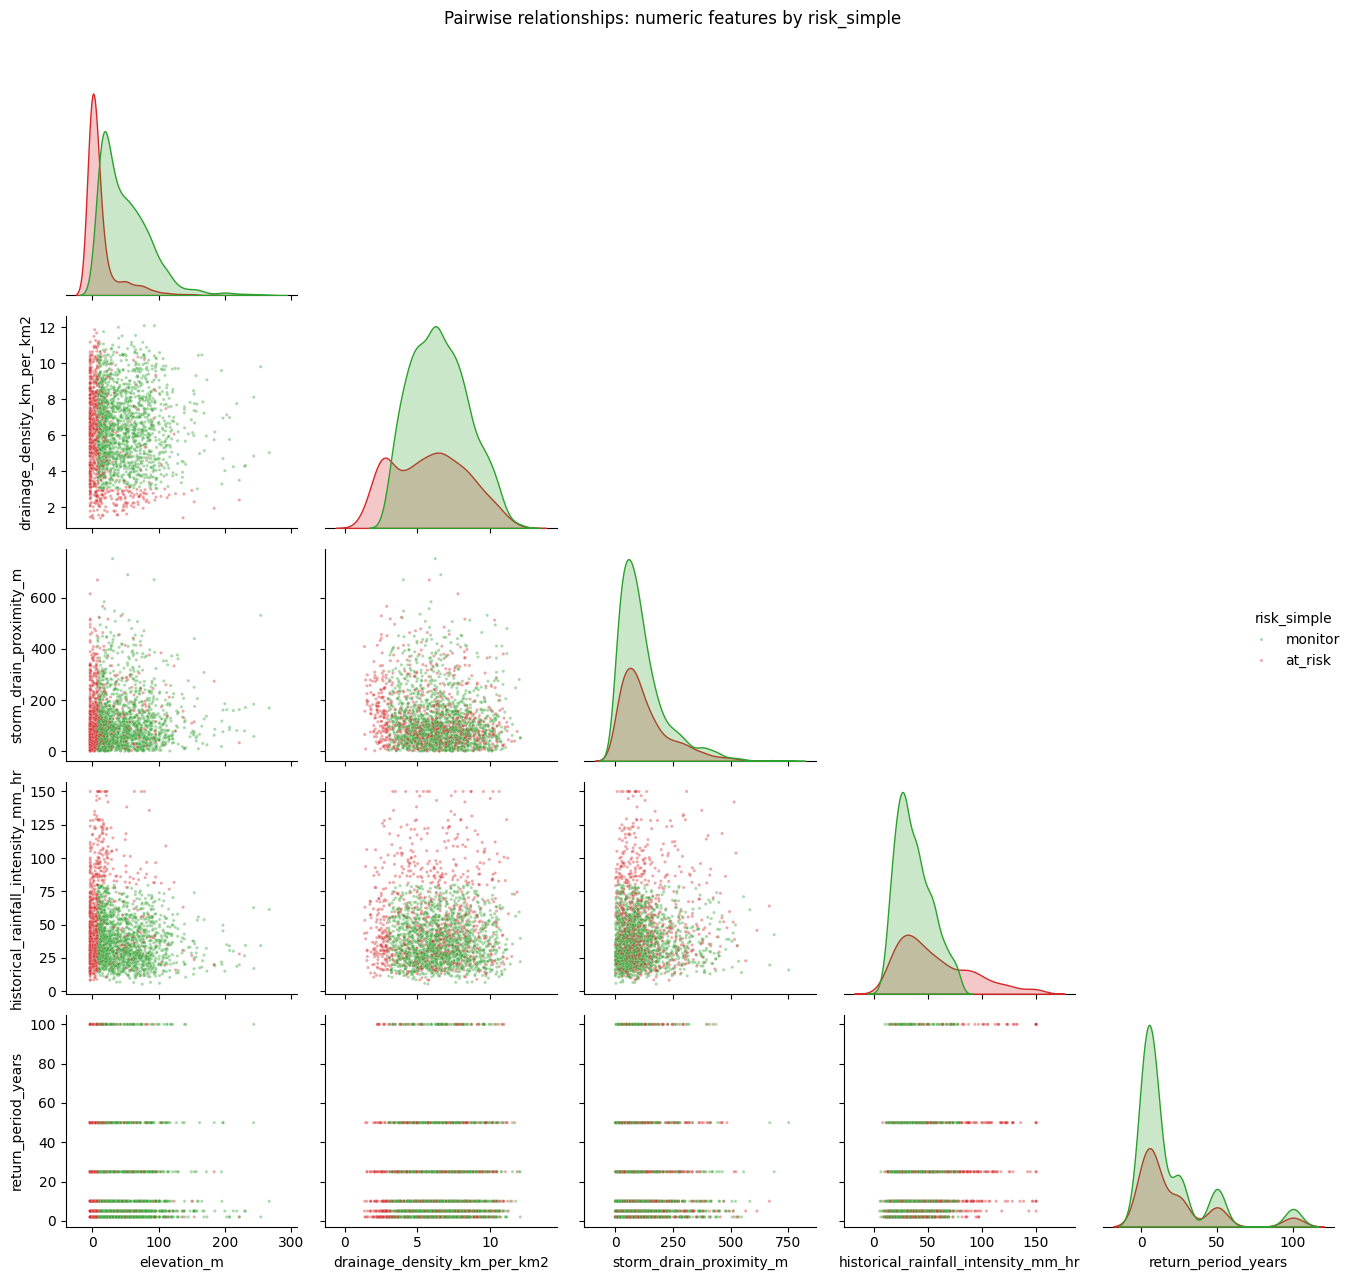

In [ ]:
num_cols = ['elevation_m', 'drainage_density_km_per_km2',
            'storm_drain_proximity_m', 'historical_rainfall_intensity_mm_hr', 'return_period_years']
df2 = df[num_cols + ['risk_simple']].dropna()

g = sns.PairGrid(df2, hue='risk_simple', palette={'monitor':'#2ca02c','at_risk':'#d62728'},
                 vars=num_cols, corner=True, diag_sharey=False, height=2.5)
g.map_lower(sns.scatterplot, alpha=0.4, s=5)
g.map_diag(sns.kdeplot, fill=True)
g.add_legend()
plt.suptitle("Pairwise relationships: numeric features by risk_simple", y=1.02)
plt.tight_layout()
plt.show()


**It shows**
* Pairwise plots giving scatterplots for each pair of numeric features (e.g. elevation vs. drainage density, elevation vs. rainfall) and density plots on the diagonals.
* We can see where at_risk vs monitor segments cluster or overlap across different feature pairs.

**Why**:
* Helps detect combinations of features that are highly predictive (e.g. low elevation + high rainfall).
* Helps understand feature correlations (if two features are strongly correlated, may drop one or combine).

##**Insight2:** Rainfall Intesity vs Risk Ratio

In [ ]:
import plotly.express as px
import plotly.offline as pyo

pyo.init_notebook_mode(connected=True)

city_group = df.groupby('city_name').agg({
    'latitude':'mean', 'longitude':'mean',
    'historical_rainfall_intensity_mm_hr':'mean',
    'risk_simple': lambda x: (x=='at_risk').mean()
}).reset_index().dropna()

city_group['risk_ratio'] = city_group['risk_simple']  # fraction of at_risk segments

fig = px.scatter_mapbox(city_group, lat='latitude', lon='longitude',
                        size='historical_rainfall_intensity_mm_hr',
                        color='risk_ratio',
                        hover_name='city_name',
                        hover_data={'historical_rainfall_intensity_mm_hr':True, 'risk_ratio':True},
                        color_continuous_scale='Reds',
                        size_max=25, zoom=5, mapbox_style='carto-positron')
fig.update_layout(title="Cities: Rainfall Intensity vs Risk Ratio", margin={"r":0,"t":30,"l":0,"b":0})
pyo.iplot(fig)

**It shows:**
* Each city is a bubble on a map; bubble size = average rainfall intensity; color = proportion of segments at risk in that city.
* Allows seeing which cities have both high rainfall and high risk.

**Why:**
* Prioritize resource allocation by city: which few cities should get attention first (those with large bubbles and dark colors).
* Helps bring in geospatial insights; executives often understand maps more intuitively than tables.

In [ ]:
!pip install joypy

##**Insight3:** Rainfall intensity distribution by top risk label types

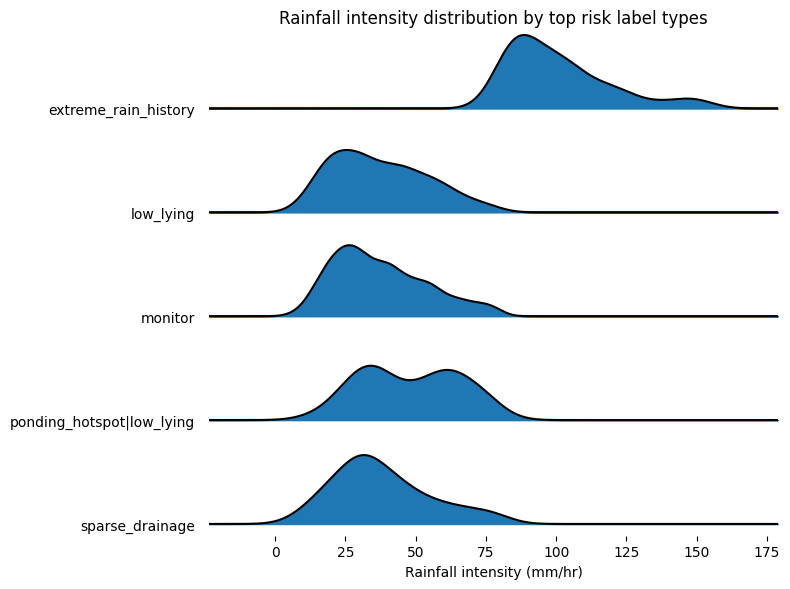

In [ ]:
import joypy

# Filter top risk labels
top_risk_labels = df['risk_labels'].value_counts().nlargest(5).index.tolist()
df_r = df[df['risk_labels'].isin(top_risk_labels)]

# Prepare data
data_for_ridges = [df_r[df_r['risk_labels']==rl]['historical_rainfall_intensity_mm_hr'].dropna() for rl in top_risk_labels]

fig, axes = joypy.joyplot(df_r, by='risk_labels', column='historical_rainfall_intensity_mm_hr',
                          kind='kde', overlap=0.5, figsize=(8,6),
                          title="Rainfall intensity distribution by top risk label types")
plt.xlabel("Rainfall intensity (mm/hr)")
plt.tight_layout()
plt.show()


* Overlapping density curves (ridgelines) for several of the top risk categories.
* Visually compare how rainfall intensity distribution shifts across risk types.

**Why:**
* For categories like “extreme_rain_history”, you can see they have heavier tails (more high intensity).
* Helps identify whether risk labels map cleanly to environmental stressors.

##**Insight4:** Spider / Radar chart comparing feature profiles of typical high-risk vs typical monitor segments

In [ ]:
import plotly.graph_objects as go
import plotly.offline as pyo

pyo.init_notebook_mode(connected=True)

profile_cols = ['elevation_m','drainage_density_km_per_km2',
                'storm_drain_proximity_m','historical_rainfall_intensity_mm_hr','return_period_years']
agg_monitor = df[df['risk_simple']=='monitor'][profile_cols].median().fillna(0)
agg_atrisk = df[df['risk_simple']=='at_risk'][profile_cols].median().fillna(0)

categories = profile_cols

fig = go.Figure()

fig.add_trace(go.Scatterpolar(
    r=agg_monitor.values,
    theta=categories,
    fill='toself',
    name='Monitor'
))
fig.add_trace(go.Scatterpolar(
    r=agg_atrisk.values,
    theta=categories,
    fill='toself',
    name='At Risk'
))

fig.update_layout(polar=dict(
    radialaxis=dict(visible=True)),
    title="Feature profile (median) of Monitor vs At-Risk segments",
    showlegend=True
)
pyo.iplot(fig)

* The radar plots compare multiple features simultaneously for the two risk groups.
* You see relative strengths/weaker features: e.g. monitor segments might have higher elevation and lower rainfall while at_risk have worse scores across features.

Helps in:

* Helps stakeholders understand trade-offs: which features are most different, and what interventions might shift a segment’s radar profile toward safer.

##**Insight5:** Flow / Return Period vs Elevation curve plot

/tmp/ipython-input-2108120198.py:4: FutureWarning:



The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.




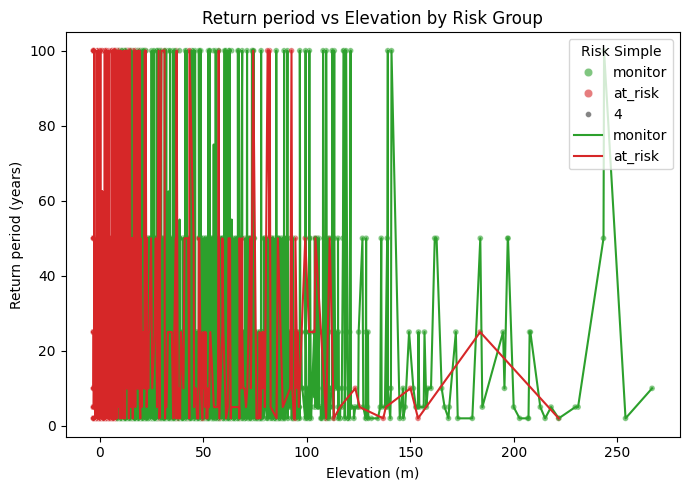

In [ ]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x='elevation_m', y='return_period_years',
                hue='risk_simple', alpha=0.6, palette=colors, size=4)
sns.lineplot(data=df_num.assign(risk_simple=df['risk_simple']),
             x='elevation_m', y='return_period_years', hue='risk_simple',
             palette=colors, estimator='median', ci=None)
plt.xlabel("Elevation (m)")
plt.ylabel("Return period (years)")
plt.title("Return period vs Elevation by Risk Group")
plt.legend(title="Risk Simple")
plt.tight_layout()
plt.show()


* Scatter plus median trend line: how return periods of heavy rainfall relate to elevation for monitor vs at_risk.
* Might show that, for at_risk, even moderate elevation segments have worse return period (i.e. frequent heavy rainfall events) than similar elevation monitor segments.

**Why:**
Helps understand whether elevation alone is protective, or whether rainfall frequency overwhelms elevation.

# **Strengths of the EDA Pipeline**

>Comprehensive Data Cleaning – The dataset was thoroughly checked for missing values, duplicates, and inconsistencies, ensuring reliable analysis.

>Variety of Visualization Techniques – Advanced visualization methods (heatmaps, violin plots, waffle charts, density plots) were used to extract hidden patterns, moving beyond basic bar and pie charts.

>Meaningful Insights – The pipeline focused on extracting business-relevant insights, such as rainfall impact, drainage efficiency, and urban vulnerabilities, rather than trivial patterns.

>Scalability – The framework can easily be extended to incorporate new datasets (e.g., climate change projections or real-time IoT flood sensors).

# **Limitations:**

1)Static Historical Data – The dataset does not represent real-time conditions, so predictions may not reflect sudden weather anomalies.

2)Limited Geographical Context – Without precise geospatial data (latitude/longitude), the analysis cannot fully model localized flood risks.

3)Simplified Risk Factors – Flooding is influenced by multiple factors (urban planning, soil absorption, infrastructure quality), but only a subset is covered here.

# **Key Insights and Implications for the Business**

**Rainfall-Drainage Relationship** – Heavy rainfall with poor drainage is the strongest predictor of flood occurrence, highlighting the urgent need for drainage system improvements.

**Urban Density vs. Flood Risk** – Highly urbanized areas show disproportionately higher flood incidents, suggesting zoning and green infrastructure policies could mitigate risks.

**Elevation Factor** – Lower elevation zones are consistently correlated with higher flood severity, reinforcing the importance of risk-based urban planning.

**Seasonality** – Flooding shows clear seasonal patterns, helping companies and governments plan early interventions and resource allocation.

# **Data-Driven Recommendations**

1)Infrastructure Investment – Prioritize drainage upgrades in flood-prone low-elevation areas.

2)Urban Green Planning – Introduce permeable pavements, green roofs, and rain gardens in high-density cities to reduce surface runoff.

3)Early Warning Systems – Leverage rainfall forecasts with the dataset to build predictive alerts for disaster management.

4)Insurance & Risk Assessment – Businesses (especially insurers and real estate) can use these insights to design risk-adjusted premiums and guide urban development policies.

5)Future Data Collection – Integrating geospatial, IoT, and climate simulation data would enhance predictive power and support real-time flood risk dashboards.

# **Conclusion**



This EDA pipeline has demonstrated how structured data analysis and advanced visualization can uncover critical flood risk patterns. While there are data limitations, the insights are actionable and can significantly help urban planners, policymakers, insurers, and businesses reduce financial and human losses. With further integration of real-time and geospatial data, this pipeline can evolve into a decision-support system for smarter, more resilient urban infrastructure.